# 2. 端到端机器学习项目

假设我们是一家房地产公司聘请的数据科学家,完成一个端到端示例项目

我们将主要完成的步骤:
1.  界定问题并审视全局。
2.  获取数据。
3.  探索数据以获得洞察。
4.  准备数据，以便更好地向机器学习算法暴露底层数据模式。
5.  探索多种不同模型，并筛选出最佳模型。
6.  微调模型，并将其组合成优秀的解决方案。
7.  展示你的解决方案。
8.  启动、监控并维护你的系统。


## 2.1 使用真实数据

当我们学习机器学习时最好使用真实数据.有很多的开放数据可以获取

## 2.2 放眼大局

### 2.2.1 框定问题

首先问老板业务目标是什么?公司将如何从模型受益?----决定我如何框定问题,选择哪些算法,使用哪种性能指标评估    
A:老板回答将房价中位数的预测和其他信息输入另一个机器学习系统,评估该区域是否值得投资  

下一个问当前的解决方案是什么? 作为一个参考  
A:专家手动评估

然后可以开始设计我的系统. 什么样的训练监督? 回归or分类? 批量学习or在线?  
显然: 监督学习,单变量回归,没有连续的数据流输入,数据量不大,批量即可  
>数据量很大时: 拆分到多个服务器(MapReduce技术)or在线学习

### 2.2.2 选择性能指标

回归问题,典型的为均方根误差(Root Mean Square Error,RMSE)&ensp;&ensp;*$L_2范数$* 

也可以考虑别的,如果有很多异常地区,可以考虑平均绝对误差(Mean Absolute Error,MAE)&ensp;&ensp;*$L_1范数$*

<span style="color:#6B8CBE;font-weight:600;font-size:16px">范数指数越高,它就越关注大值而忽略小值</span>

### 2.2.3 检查假设

最后,列出并检查前面所做的假设  
比如:负责下游系统的团队不是直接使用我的价格,而是转换为类别("便宜""中等"),那么我就应该是做分类而不是回归

## 2.3 获取数据

### 2.3.1 使用 google colab 运行代码

### 2.3.2 下载数据

In [1]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

In [2]:
def load_housing_data():
    # 定义路径
    tarball_path = Path("~/Downloads/housing.tgz").expanduser()
    csv_path = Path("~/AllNote/ML-DL_note/Hands-On_ML_withSklearn/datasets/").expanduser()
    # Path中 ~ 不会被自动扩展为用户的主目录
    
    # 如果 CSV 文件不存在，则需要准备数据
    if not csv_path.is_file():
        # 解压 tgz 文件到目标目录
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path=csv_path,filter='data') #filter:安全措施
    
    # 现在 CSV 文件应当存在，读取并返回
    return pd.read_csv(csv_path/'housing/housing.csv')

In [3]:
housing=load_housing_data()

### 2.3.3 快速浏览数据结构

#### 1. head()

In [4]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


#### 2. info()  数据快速描述

In [5]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


看到`total_bedrooms`有缺失值,待会需要处理; `ocean_proximity`是object,查看,判断应该是分类属性

In [6]:
housing['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

#### 3. describe() 数字属性的摘要

In [7]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


#### 4. 对整个数据集调用 hist() 方法绘制直方图

In [8]:
import matplotlib.pyplot as plt
%matplotlib inline

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

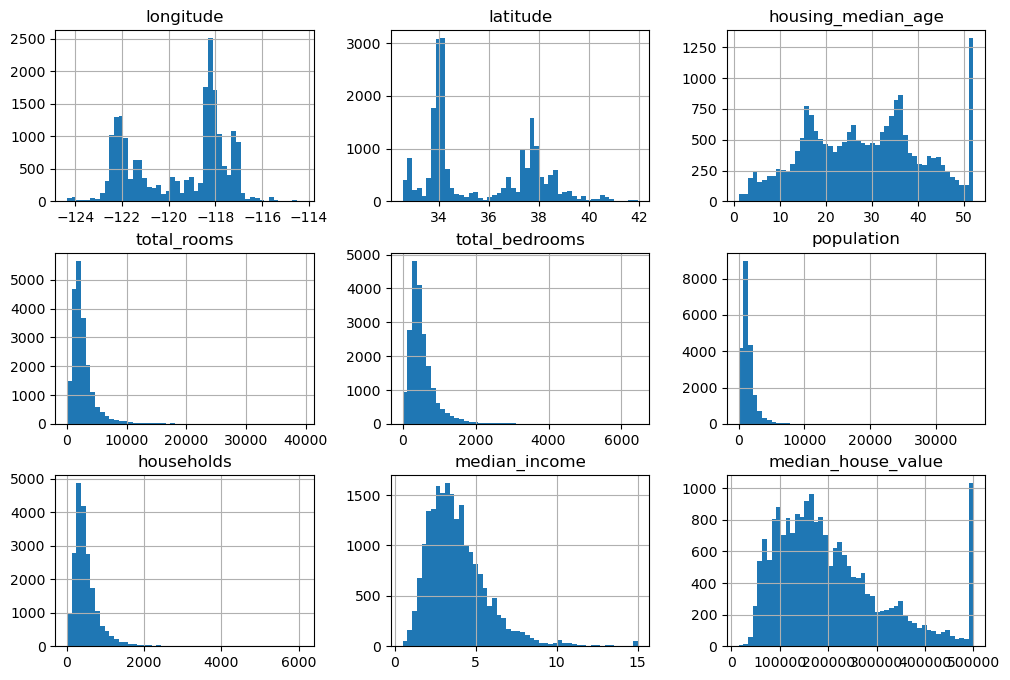

In [9]:
housing.hist(bins=50,figsize=(12,8))

从直方图中,我们可以注意到一些事情:
1. 收入中位数属性看起来不是以美元表示的. 在询问收集数据的团队后,你得知数据已按比例缩放至$(0.5,15)$. 不过这不一定是个问题.
2. 房屋年龄中位数和房价中位数也有上限,超出某个最大值的数据都被化为该最大值. 后者可能是一个严重的问题,它是我的目标属性,会导致机器学习算法学到的价格可能永远超不过500 000. 我需要与下流团队沟通,如果他们需要超过500 000美元的精确预测,此时有两个选择:
   1. 为标签被封顶的地区收集合适的标签
   2. 从训练集和测试集中删除这些数据
3. 这些数据尺度不同,需要normalize
4. 许多直方图向右倾斜,对学习算法不利,需要处理

### 2.3.4 创建测试集

在进一步查看数据前,我们就应该先创建测试集,然后永远不要看它.  
我们的大脑极易发生过拟合.我们观察数据可能会发现某种规律,导致选择一种特殊的模型,进而导致盲目乐观...  
这称为**数据窥探偏差**

测试集通常占20%,如果数据集更大,则占比更小

#### 1. 简单地随机选取一些实例

In [10]:
import numpy as np

In [11]:
def shuffle_and_split_data(data,test_ratio):
    shuffled_indices=np.random.permutation(len(data))
    #Randomly permute a sequence, or return a permuted range.
    test_set_size=int(len(data)*test_ratio)
    test_indices=shuffled_indices[:test_set_size]
    train_indices=shuffled_indices[test_set_size:]
    return data.iloc[train_indices],data.iloc[test_indices]

In [12]:
train_set,test_set=shuffle_and_split_data(housing,0.2)
len(train_set),len(test_set)

(16512, 4128)

但是这并不完美:再次运行程序,将产生不同的测试集,随时间的推移,算法将看到所有测试集,这是应当避免的<span style="font-weight:400;font-size:12px">(暂时感觉貌似没什么,嗯,看后文)</span>  
一种解决方案是在第一次运行时保存测试集,后面加载; 另一种方案是设置随机数生成器种子.  
但是这两种方法在数据集更新后仍然会失效,so:

#### 2. 使用每个实例的标识符来决定(假设有)

eg: 计算每个实例标识符的哈希值,如果小于等于最大哈希值的20%,则将该实例放入测试集中.这可以保证数据集更新后也是新数据中的20%会被放入测试集,而原数据照旧

In [13]:
# 2中所述的一个可能实现
from zlib import crc32

def is_id_in_test_set(identifier, test_ratio):
    return crc32(np.int64(identifier))<test_ratio*2**32

def split_data_with_id_hash(data, test_ratio, id_column):
    ids=data[id_column]
    in_test_set=ids.apply(lambda id_: is_id_in_test_set(id_,test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

不幸的是房屋数据没有标识符列,最简单的方法是使用*行索引*

In [14]:
housing_with_id=housing.reset_index() # add an 'index' column

In [15]:
train_set, test_set=split_data_with_id_hash(housing_with_id,
                                            0.2,
                                            'index',)

In [16]:
len(train_set),len(test_set)

(16512, 4128)

使用行索引,需要确保新数据加在数据集末尾并且不会删除任何行.  
否则,需要尝试手动构造标识符  
<span style="color:red;font-weight:600;font-size:16px">ATTENTION:</span> 手动构造容易引入采样偏差

<span style="color:#6B8CBE;font-weight:600;font-size:16px">感觉对新数据单独采样分割,然后和原数据训练集测试集拼接,应该也行.</span>

#### 3. scikit-learn提供了一些函数用来拆分数据集

内部实现与前面的shuffle_and_split_data()几乎相同,但有几个附加功能:
1. random_state参数允许设置随机生成器种子
2. 可传入多个有相同行数的数据集,它会在相同索引上拆分它们

In [17]:
from sklearn.model_selection import train_test_split
train_set, test_set=train_test_split(housing, test_size=0.2, random_state=42)

我们前面讨论的三种方法都是纯随机采样. 如果数据集相对于属性足够大,这通常没有问题.但如果不够大,就有引入**显著采样偏差**的风险,此时就需要**分层采样**.

#### 4.分层采样

假设我们和专家聊天,得知收入中位数是预测房价的重要属性. 由于收入中位数是连续的数值属性,我们首先需要创建一个收入类别属性,分层,层不能太多也不能太小,保证每一层的样本量足够.  
我们观察再次观察收入中位数直方图:

<Axes: ylabel='Frequency'>

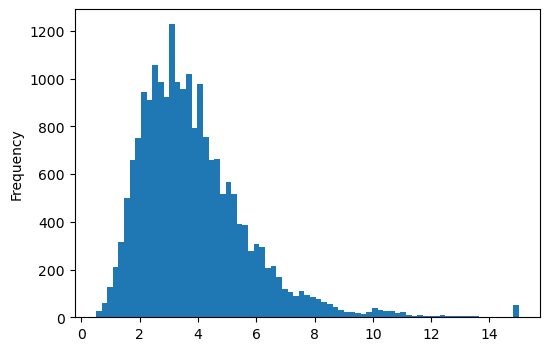

In [18]:
housing['median_income'].plot.hist(bins=75,figsize=(6,4))

大多数集中在0.5~6之间.所以:

In [19]:
housing['income_cat']=pd.cut(housing['median_income'],
                            bins=[0., 1.5, 3.0, 4.5, 6.0, np.inf],
                            labels=[1,2,3,4,5])

<Axes: xlabel='Income category', ylabel='Number of districts'>

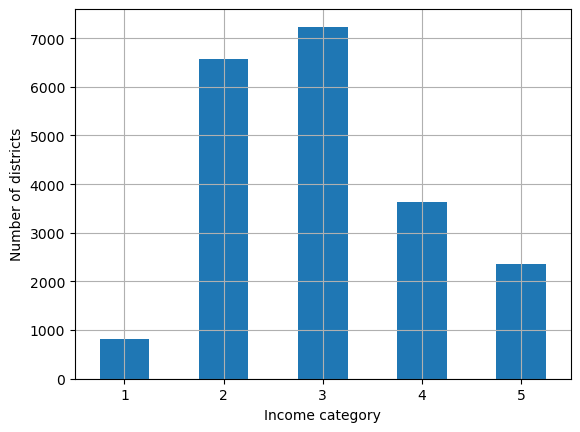

In [20]:
housing['income_cat'].value_counts().sort_index()\
    .plot.bar(rot=0, grid=True,xlabel='Income category',ylabel='Number of districts')

现在,我们可以根据收入类别进行分层采样.SciKit-Learn在`sklearn.model_selection`包中提供了许多拆分类,它们实现了各种拆分策略. 每个拆分器有一个`split()`方法,产生训练和测试指标(返回迭代器)

In [21]:
from sklearn.model_selection import StratifiedShuffleSplit

In [22]:
splitter=StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
strat_splits=[]
for train_index, test_index in splitter.split(housing, housing['income_cat']):
    strat_train_set_n=housing.iloc[train_index]
    strat_test_set_n=housing.iloc[test_index]
    strat_splits.append([strat_train_set_n,strat_test_set_n])

In [23]:
strat_train_set, strat_test_set=strat_splits[0]

上面将数据分成了10份,当然,后面交叉验证会用到.  
我们也可以简单地使用带有`stratify`参数的`train_test_split()`获得单个拆分

In [24]:
strat_train_set, strat_test_set=train_test_split(
    housing,test_size=0.2,stratify=housing['income_cat'],random_state=42)

检查一下是否按预期工作:

In [25]:
strat_test_set["income_cat"].value_counts()/len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

后面不会再使用income_cat列,因此不妨删除它

In [26]:
for set_ in (strat_train_set,strat_test_set):
    if "income_cat" in set_.columns:
        set_.drop("income_cat",axis=1,inplace=True) # default False,return a copy

## 2.4  探索和可视化数据以获得见解

到目前为止,我们只是大致浏览了数据.现在开始深入.  
*把测试集放在一边不管.*

如果训练集太大,我们需要采样一个探索集便于操作.这里训练集不大可以直接操作.  
在操作之前,先制作一份原始副本,以便之后可以恢复

In [27]:
house=strat_train_set.copy()

In [28]:
house.shape

(16512, 10)

### 2.4.1 可视化地理数据

数据集中包含地理信息(经纬度),我们可以使用散点图来可视化观察

<Axes: xlabel='longitude', ylabel='latitude'>

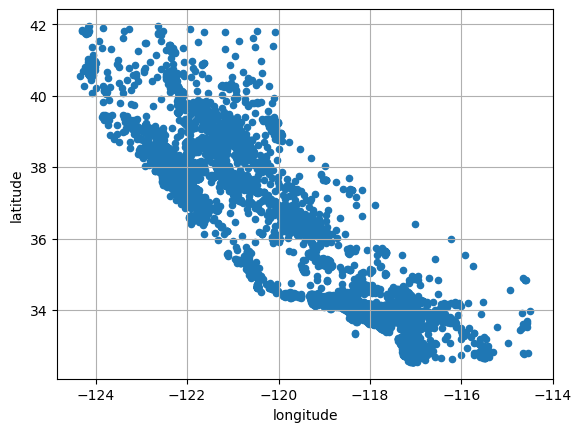

In [29]:
house.plot(kind='scatter',x='longitude',y='latitude',grid=True)

嗯,这只能看出地图的大致形状... 将 alpha 设置为 0.2 ,可以可视化出数据点密度高的地方

<Axes: xlabel='longitude', ylabel='latitude'>

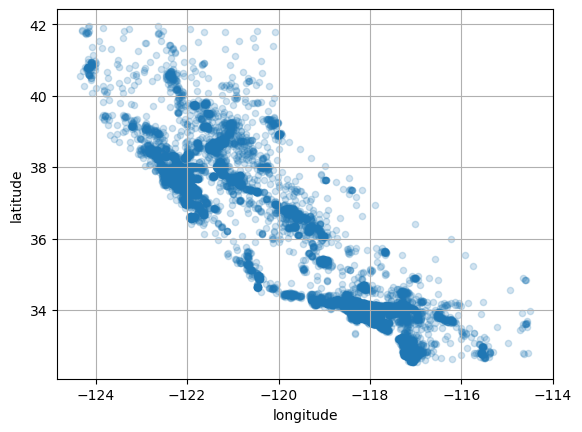

In [30]:
house.plot(kind='scatter',x='longitude',y='latitude',grid=True,alpha=0.2)

接下来看看房价:  
- 每个圆圈的半径代表该地区的人口数量(选项 s )
- 颜色代表价格(选项 c )
- 使用名为 jet 的预定义颜色图(选项 cmap ),其范围从蓝色(低)到红色(高)

<Axes: xlabel='longitude', ylabel='latitude'>

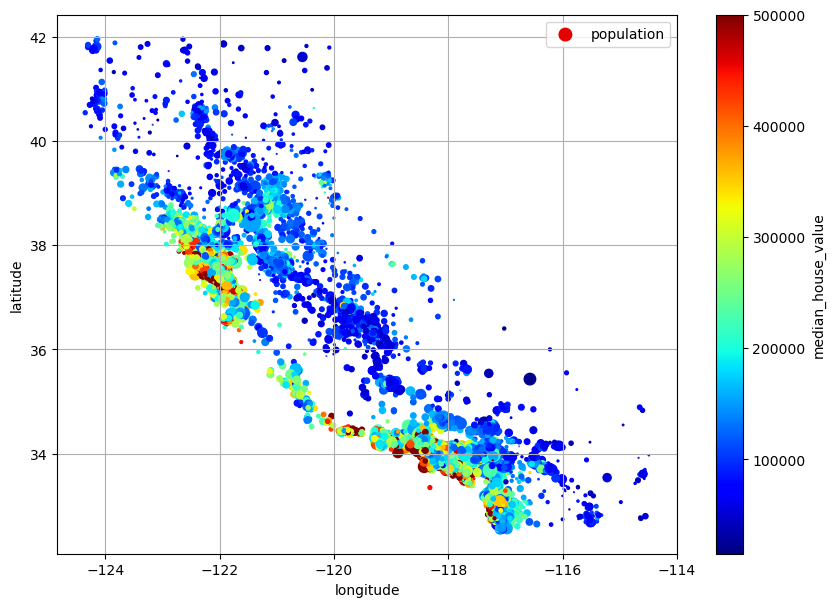

In [31]:
house.plot(kind='scatter',x='longitude',y='latitude',grid=True,
           s=house['population']/100,label='population',
           c='median_house_value',
           cmap='jet',colorbar=True,legend=True,sharex=False,figsize=(10,7),
          )

可以看到,房价与地理位置,人口密度密切相关.  
聚类算法应该有助于检测主集群和添加新特征来衡量与集群中心的接近程度.  

### 2.4.2 寻找相关性

1. 由于数据集不是太大,可以使用`corr()`方法轻松计算每对属性之间的标准相关性(线性相关性):

In [32]:
corr_matrix=house.corr(numeric_only=True) #忽略非数值列

In [33]:
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

可以看到房价中位数与收入中位数有较强的正相关,与维度有一定的负相关

2. 查看属性之间相关性的另一种方法是使用Pandas的`scatter_matrix()`函数  
   如果每一个都对比,将会有 $11^2=121$ 张图,太多了,所以我们选择一些看起来最相关的.

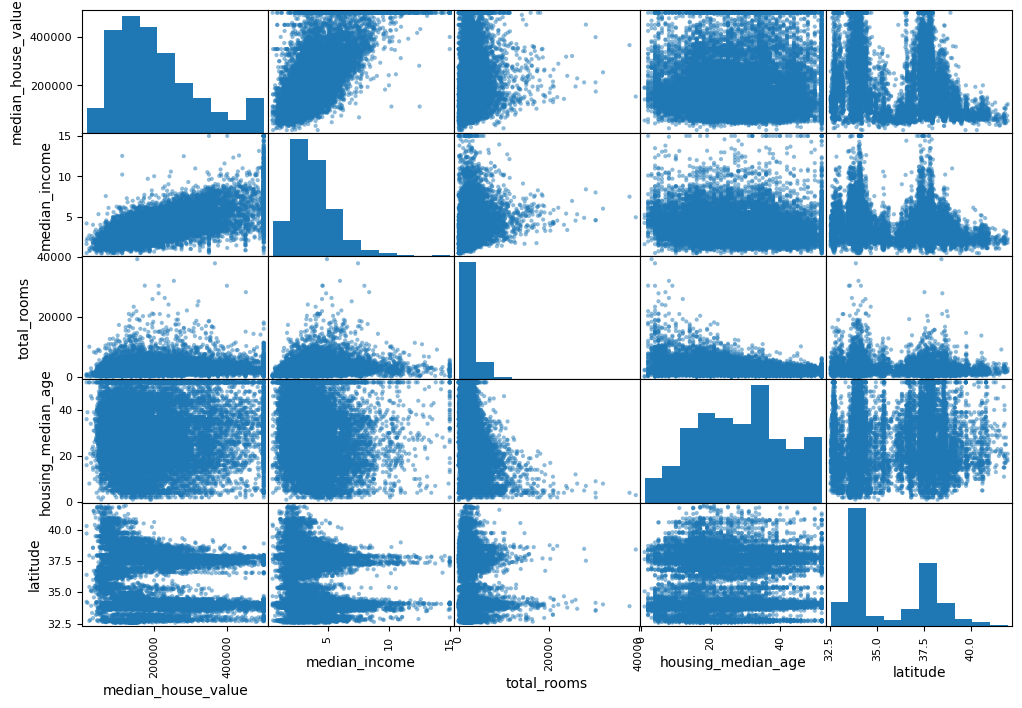

In [34]:
attributes=['median_house_value','median_income','total_rooms','housing_median_age','latitude']
pd.plotting.scatter_matrix(house[attributes],figsize=(12,8));

结合前面两者,最"好"的属性似乎是收入中位数,我们可以放大散点图:

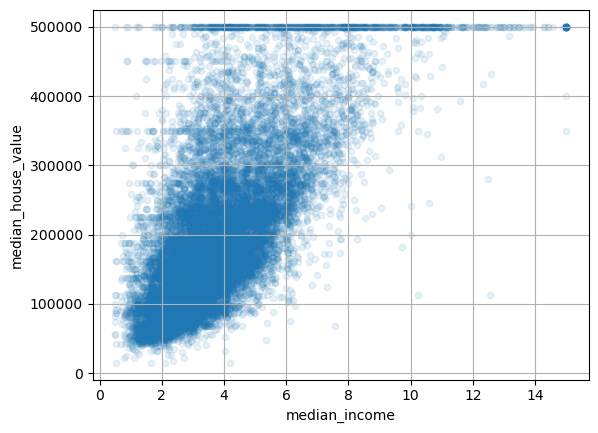

In [35]:
house.plot.scatter(x='median_income',y='median_house_value',alpha=0.1,grid=True);

这个图揭示了一些事情:
1. 相关性确实很好,而且点比较集中
2. 之前注意到的500,000美元价格上限清晰可见;除此之外,450,000, 350,000也有一条水平线,280,000附近似乎也有,  
   你可能想去掉这些数据

### 2.4.3 实验不同的属性组合

有时候单独的某个属性可能和目标属性关系不大,但是将它和别的属性组合起来也许会有意想不到的效果,能够发现一些非线性关系.  
eg: 卧室总数本身并不是很有用,我们可以考虑把它和其他房间数量进行比较...



In [36]:
house['rooms_per_house']=house['total_rooms']/house['households']
house['bedrooms_ratio']=house['total_bedrooms']/house['total_rooms']
house['people_per_house']=house['population']/house['households']

In [37]:
corr_matrix=house.corr(numeric_only=True)
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
rooms_per_house       0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
people_per_house     -0.038224
longitude            -0.050859
latitude             -0.139584
bedrooms_ratio       -0.256397
Name: median_house_value, dtype: float64

还不错,bedrooms_ratio与房价中位数关系更大  

这一轮探索不需要很彻底,关键是要从正确的脚步开始并快速获得见解,这将帮助我们获得第一个相当不错的原型.  
但这是一个<mark>迭代</mark>的过程: 一旦我们启动并运行了第一个原型,就可以分析它的输出来获得更多见解并回到这个探索步骤

## 2.5 为机器学习算法准备数据

是时候准备数据了,我们应当为这个目的编写函数而不是手动操作,原因如下:
1. 可以在任何数据集上复现
2. 可以逐步构建一个可在未来项目中重现的转换函数库
3. 可以在实时系统中使用这些函数来转换新数据,并提供给算法
4. 可以轻松尝试不同转换的组合

但首先,要恢复干净的数据集,并将预测变量和标签分开(不一定对预测变量和目标值使用相同变换)

In [38]:
housing=strat_train_set.drop("median_house_value",axis=1) # 返回副本
housing_labels=strat_train_set["median_house_value"].copy()

### 2.5.1 清洗数据(处理缺失值)

大多数算法无法处理缺失特征.我们有三个选择:
1. 去掉相应的样本
2. 去掉整个属性
3. 将缺失值设置为某个值(0,mean,median).这称为归责
```python
housing.dropna(subset=["total_bedrooms"], inplace=True)    # option 1

housing.drop("total_bedrooms", axis=1)       # option 2

median = housing["total_bedrooms"].median()  # option 3
housing["total_bedrooms"].fillna(median, inplace=True)
```
选择通常方法3,它的破坏性最小.  
但是我们将使用SciKit-Learn提供的`SimpleImputer`类实现.它将存储每一个特征的中位数值,不仅可以在训练集上估算,也可以在验证集/测试集上和新数据上估算缺失值.

In [39]:
from sklearn.impute import SimpleImputer

imputer=SimpleImputer(strategy='median')

In [40]:
housing_num=housing.select_dtypes(include=[np.number]) #这个imputer只能在数值属性上使用

In [41]:
imputer.fit(housing_num) #使用fit()方法将imputer实例拟合到训练数据中

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


imputer简单计算了每个属性的中位数并存储在它的`statistics_`实例变量中.  

In [42]:
imputer.statistics_, housing_num.median().values

(array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
         408.    ,    3.5385]),
 array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
         408.    ,    3.5385]))

现在可以用这个"训练有素"的imputer来通过用学习到的中位数替换nan来转换缺失值.  
注: 虽然housing中只有total_bedrooms属性有缺失值,但不能保证以后的新数据不会有nan,所有对所有数值属性应用imputer更安全; 这也更方便

In [43]:
X=imputer.transform(housing_num)

转换器输出Numpy数组(有时是SciPy稀疏矩阵)

In [44]:
housing_tr=pd.DataFrame(X,index=housing_num.index,columns=housing_num.columns)

缺失值也可以替换为平均值（strategy="mean"）, 或替换为最频繁的值（strategy="most_frequent"），或替换为常数值（strategy="constant", fill_value=...）. 最后两种策略支持非数值数据。

>`sklearn.impute` 包中还有更强大的 imputers（两者都仅用于数值特征）：
>- `KNNImputer` 将每个缺失值替换为该特征的 k 近邻的平均值。该距离基于所有可用的特征。
>- `IterativeImputer` 为每个特征训练一个回归模型，以根据所有其他可用特征预测缺失值。然后，它会根据更新后的数据再次训练模型，并多次重复该过程，在每次迭代中改进模型和替换值。

### 补充:SciKit-Learn的设计

<span style="font-weight:600;font-size:16px">SciKit-Learn API 的主要设计原则:</span>
- 一致性&ensp;&ensp;所有对象共享一个一致且简单的接口
- 估计器&ensp;&ensp;任何可以根据数据集估计某些参数的对象都称为估计器.  
  - 估计本身由`fit()`方法实现
- 转换器&ensp;&ensp;一些估计器可以转换数据集,这些被称为转换器(eg:SimpleImputer)  
  - 转换由`transform()`方法执行.
  - 还有一个`fit_transform()`的便捷方法,先调用fit()再调用transform(),不过有时会经过优化
- 预测器&ensp;&ensp;一些估计器在给定数据集的情况下能够进行预测,这些被称为预测器.
  - 预测器有一个`predict()`方法,输入新实例的数据集,返回相应预测的数据集
  - 还有一个`score()`方法,在给定测试集(&标签)的情况下测量预测的质量/可信度
- 检查
  - 所有估计器的超参数都可以通过公开实例变量直接访问(eg: imputer.strategy)
  - 学习参数可以通过带有下划线后缀的公共实例变量访问(eg: imputer.statistics_)
- 防止类扩散&ensp;&ensp;数据集表示为Numpy数组或SciPy稀疏矩阵; 超参数是常规的python对象
- 构成&ensp;&ensp;尽可能复用鲜藕的构建块
- 合理的默认值&ensp;&ensp;SciKit-Learn为大多数参数提供了合理的默认值

### 2.5.2 处理文本和类别属性

In [45]:
housing_cat=housing[["ocean_proximity"]]
housing_cat.head(8)

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN
1286,INLAND
18078,<1H OCEAN
4396,NEAR BAY


#### 1. 我们可以使用SciKit-Learn的`OrdinalEncoder`类将这些类别从文本转换为数字

In [46]:
from sklearn.preprocessing import OrdinalEncoder

In [47]:
ordinal_encoder=OrdinalEncoder()
housing_cat_encoded=ordinal_encoder.fit_transform(housing_cat)

In [48]:
housing_cat_encoded[:8],housing_cat_encoded.shape

(array([[3.],
        [0.],
        [1.],
        [1.],
        [4.],
        [1.],
        [0.],
        [3.]]),
 (16512, 1))

可以使用`categories_`实例变量来获取类别列表.它是一个包含每个分类属性的一位类别数组的列表(本例中只有一个分类属性,所以列表中只有一项)

In [49]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

这种表示的坏处是引入了假设 "两个距离较近的值比两个距离较远的值更相似; 不同的值之间有顺序" .  
因此在某些情况下就会由问题. 此时我们采用**独热编码**.  

#### 2. 独热编码/虚拟属性

ps: 有些属性为1(热), 有些属性为0(冷)

SciKit-Learn提供了一个`OneHotEncoder`类

In [50]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_1hot=cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

默认情况下,OneHotEncoder输出为SciPy稀疏矩阵  

对于主要包含 0 的矩阵,稀疏矩阵是一种非常有效的表示. 它内部仅存储非零值及其位置, 可以节省大量内存并加快计算速度.  
可以像普通二维数组一样使用稀疏矩阵,也可以调用`toarray()`方法将其转换为numpy数组

In [51]:
housing_cat_1hot.toarray()

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]], shape=(16512, 5))

或者,可以在创建时设置sparse=False,之后`transform()`方法将直接返回numpy数组  
```python
cat_encoder=OneHotEncoder(sparse_output=False)
```

#### 3. Pandas: get_dummies()

In [52]:
df_test=pd.DataFrame({"ocean_proximity":['INLAND','NEAR BAY']})
pd.get_dummies(df_test,dtype=float)

,ocean_proximity_INLAND,ocean_proximity_NEAR BAY
0,1.0,0.0
1,0.0,1.0


这看起来既简单又漂亮,那为什么用`OneHotEncoder`呢?  
<span style="color:#6B8CBE;font-weight:600;font-size:16px">OneHotEncoder的优势在于它会记住经过了哪些类别的训练. 这很重要, 因为模型一旦投入生产, 它应该提供与训练期间完全相同的特征: 不多也不少.</span>  
我们来看对比

1. 模型被用于预测时:  
pd.get_dummies只是把DataFrame中的类别属性转换为独热编码;  
而OneHotEncoder记住了训练时的类别数量,所以对DataFrame中没有的类别自动补0.

In [53]:
#此时不是训练, 所以只用transform
cat_encoder.transform(df_test).toarray()

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0.]])

2. 当输入一个训练时没有的类别时:  
此时get_dummies会将其变为新的一列,  
而OneHotEncoder会报错 or 可以将超参数`handle_unknown`设置为'ignore'(忽略),则会将未出现的类别视作0

In [54]:
df_test_unknown=pd.DataFrame({'ocean_proximity':['<2H OCEAN','ISLAND']})
pd.get_dummies(df_test_unknown,dtype=float)

,ocean_proximity_<2H OCEAN,ocean_proximity_ISLAND
0,1.0,0.0
1,0.0,1.0


In [55]:
try:
    cat_encoder.transform(df_test_unknown)
except ValueError as e:
    print(e)

Found unknown categories ['<2H OCEAN'] in column 0 during transform


In [56]:
cat_encoder.handle_unknown='ignore'
cat_encoder.transform(df_test_unknown).toarray()

array([[0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0.]])

如果分类属性有大量可能的类别（例如，国家代码、职业、物种），则独热编码将导致大量输入特征。这可能会减慢训练速度并降低性能。  
如果发生这种情况，你可能希望用与类别相关的有用数值特征来替换分类输入。
- 例如，你可以将 ocean_proximity 特征替换为到海洋的距离（类似地，国家代码可以替换为国家的人口数量和人均 GDP）。
- 你也可以使用 GitHub (https://github.com/scikit-learn-contrib/category_encoders) 上的 category_encoders 包提供的编码器。
- 或者，在处理神经网络时，你可以用称为 *嵌入的可学习的低维向量* 替换每个类别。这是表示的一个示例

（更多细节参见第 13 章和第 17 章）。

----
当使用DataFrame拟合任何SciKit-Learn估计器时,估计器会将列名存储在`feature_names_in_`*属性*中.然后,SciKit-Learn确保之后馈送到该估计器的任何DataFrame(如在transform(),predict()中传入的)具有相同的列名.

Transformer(转换器)还提供了一个`get_feature_names_out()`*方法*,可以使用该方法围绕转换器的输出构建DataFrame

In [57]:
cat_encoder.feature_names_in_

array(['ocean_proximity'], dtype=object)

In [58]:
cat_encoder.get_feature_names_out()

array(['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'], dtype=object)

In [59]:
pd.DataFrame(cat_encoder.transform(df_test_unknown).toarray(), #这里稀疏矩阵要先转换为numpy
             columns=cat_encoder.get_feature_names_out(),
             index=df_test_unknown.index)

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0


### 2.5.3 特征缩放和转换

绝大多数机器学习算法在输入数值尺度差别很大时表现不佳.  
比如本例中,房间总数大约在 $6 \textasciitilde 39320$ 之间,而收入中位数仅在 $0 \textasciitilde 15$ 之间,这会使大多数模型倾向于忽略数值较小的属性  

有两种常用的方法:最小-最大缩放 和 标准化

<span style="color:red;font-weight:600;font-size:16px">ATTENTION</span>:  
与所有估计器一样，重要的是仅把缩放器拟合到训练数据：永远不要对训练集以外的任何其他对象使用 `fit()` 或 `fit_transform()`.  
一旦你有了一个训练好的缩放器，你就可以用它来 `transform()` 任何其他集合，包括验证集、测试集和新数据。请注意，虽然训练集值将始终缩放到指定范围，如果新数据包含异常值，这些值可能最终会缩放到范围之外。如果你想避免这种情况，只需将 `clip` 超参数设置为 `True`.  
<span style="color:red;font-weight:600;font-size:16px">------</span>

#### 1. 最小-最大(归一化) 
对每个属性,减去最小值并除以最大值和最小值的差 所以每个属性值最终在 $0 \textasciitilde 1$ 之间  
SciKit-Learn提供了一个名为MinMaxScaler的转换器. 他有一个feature_range超参数,可以更改最终值的范围
- eg:神经网络在0均值输入下效果更好,因此 $-1 \textasciitilde 1$ 更可取

这种方法容易受极端值影响,
- 比如大多数值在 $0 \textasciitilde 15$ 之间,有一个异常值/错误值是$100$,那么这种方法会将$100$映射到 $1$, $0 \textasciitilde 15$映射到$0 \textasciitilde 0.15$

In [60]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler=MinMaxScaler(feature_range=(-1,1))
housing_min_max_scaled=min_max_scaler.fit_transform(housing_num)

#### 2. 标准化
标准化则是 减去均值,然后除以标准差  
因此标准化后均值为0,标准差为1.  
标准化受异常值影响要小得多.

如果你想缩放稀疏矩阵而不先将其转换为密集矩阵,则可以使用`StandardScaler`, 并将其`with_mean`超参数设置为False: 它只会将数据除以标准差,而不减去均值(否则会破坏稀疏性,0被减成了别的)

In [61]:
from sklearn.preprocessing import StandardScaler

std_scaler=StandardScaler()
housing_num_std_scaled=std_scaler.fit_transform(housing_num)

#### 3. 重尾(heavy tail)
当一个特征分布有重尾时,最小-最大/标准化都会将大多数值压缩到一个小范围,而机器学习通常不喜欢那样.  
so, 在特征缩放之前,我们应该先处理重尾.  

##### 1. 对右侧有重尾的正特征,常用方法有 取平方根(或0~1次幂)/ 取对数 (根据尾巴的长度和下降的快慢来选)

<Axes: ylabel='Frequency'>

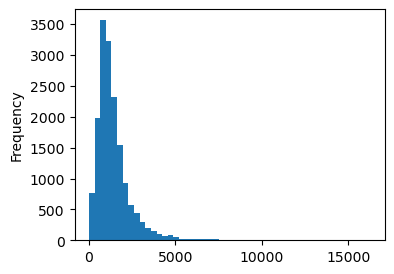

In [96]:
housing_num['population'].plot.hist(figsize=(4,3),bins=50)

<Axes: ylabel='Frequency'>

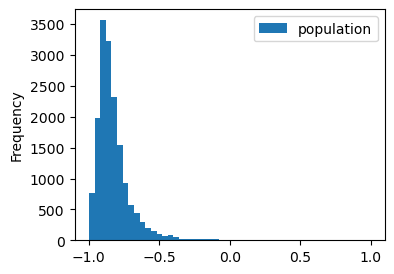

In [97]:
house_population=housing_num[['population']]
population_min_max=min_max_scaler.fit_transform(house_population)
pd.DataFrame(population_min_max,columns=house_population.columns).plot.hist(figsize=(4,3),bins=50)

<Axes: ylabel='Frequency'>

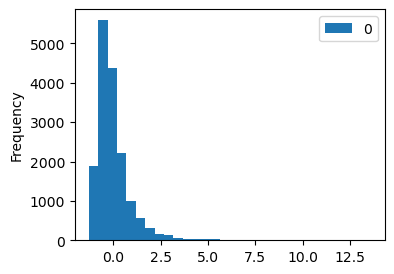

In [98]:
population_Std=std_scaler.fit_transform(house_population)
pd.DataFrame(population_Std).plot.hist(figsize=(4,3),bins=30)

<Axes: ylabel='Frequency'>

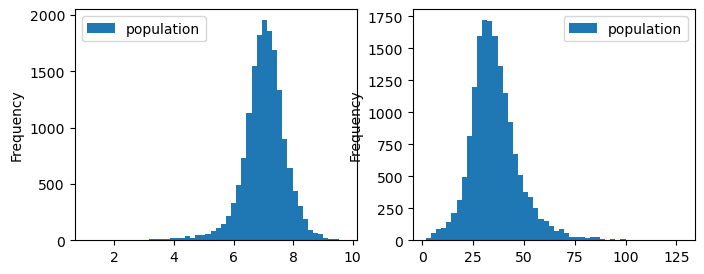

In [99]:
fig,ax=plt.subplots(1,2,figsize=(8,3))
np.log(house_population).plot.hist(ax=ax[0],bins=50)
np.sqrt(house_population).plot.hist(ax=ax[1],bins=50)

可以看到处理之后很接近高斯分布

##### 2. 处理重尾的另一种方法是分桶(bucketizing)
将其分布分成大致相等大小的桶,并用它所属的桶的索引可替换每个特征值.  
>eg: 根据百分位数分桶,将每个特征值替换为其百分位数.
  
使用大小相等的桶可以产生几乎均匀分布的特征

#### 4. 多峰  
又称为模式. 如housing_median_age特征

<Axes: ylabel='Frequency'>

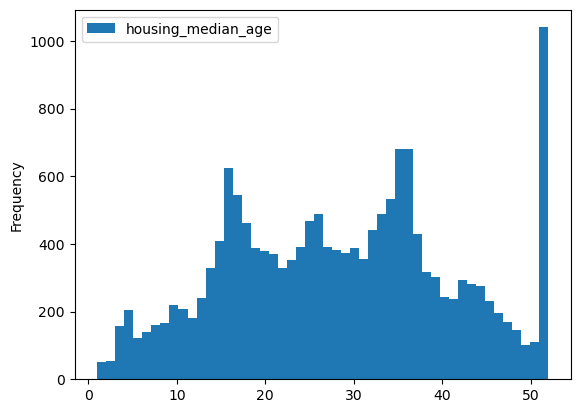

In [95]:
median_age=housing_num[['housing_median_age']]
median_age.plot(kind='hist',bins=50)

1. 双峰时分桶也很有用,但这次将桶的ID视为类别,做成分类属性,使用OneHotEncoder等编码.
   这种方法使模型更容易学习针对该特征值的不同范围的不同规则.
   >eg: 35年前的房子由于造型过时,比单凭年龄判断的价格要更低&ensp;  就更容易地可以学到这个35
2. 另一种转换多峰分布的方法是为每个主要模式(峰)添加一个特征,就本例而言,表示房屋中位数与该特定模式之间的相似性.
   就是添加特征,把多峰转换称多个单峰
   相似性度量通常使用**径向基函数**(RBF)计算--一类输出仅取决于输入和固定点之间距离的函数
   >最常用的是高斯RBF,输出随输入值远离固定点而呈指数衰减,超参数gamma决定衰减速度
   >下面的例子中,我们使用SciKit-Learn的`rbf_kernel()`函数

In [100]:
from sklearn.metrics.pairwise import rbf_kernel
age_simil_35=rbf_kernel(housing[['housing_median_age']],[[35]],gamma=0.1)

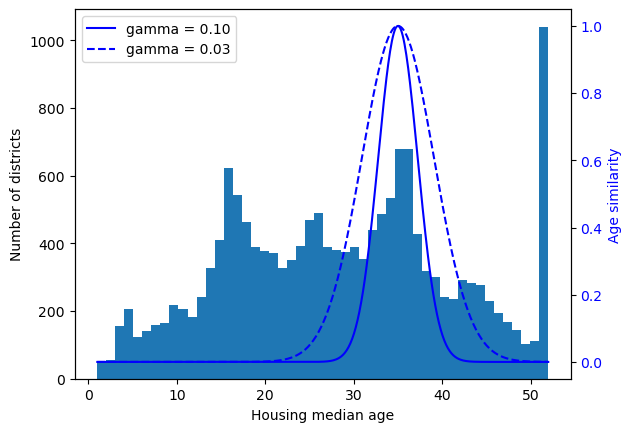

In [115]:
# extra code – this cell generates Figure 2–18

ages = np.linspace(housing["housing_median_age"].min(),
                   housing["housing_median_age"].max(),
                   500).reshape(-1, 1)
gamma1 = 0.1
gamma2 = 0.03
rbf1 = rbf_kernel(ages, [[35]], gamma=gamma1)
rbf2 = rbf_kernel(ages, [[35]], gamma=gamma2)

fig, ax1 = plt.subplots()

ax1.set_xlabel("Housing median age")
ax1.set_ylabel("Number of districts")
ax1.hist(housing["housing_median_age"], bins=50)

ax2 = ax1.twinx()  # create a twin axis that shares the same x-axis
color = "blue"
ax2.plot(ages, rbf1, color=color, label="gamma = 0.10")
ax2.plot(ages, rbf2, color=color, label="gamma = 0.03", linestyle="--")
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylabel("Age similarity", color=color)

plt.legend(loc="upper left")
plt.show()

#### 5. 逆转换
到目前为止,我们只查看了输入特征,目标值也可能需要转换. 而目标值转换之后,我们需要变回去  
幸运的是,SciKit-Learn的转换器大多数都有一个`inverse_transform()`方法.  
>eg: 下面的例子展示了如何使用StandardScaler来缩放标签,然后训练,并进行预测,使用inverse_transform()换回去.  
>注意,使用DataFrame,因为StandardScaler需要2D输入

In [116]:
from sklearn.linear_model import LinearRegression

target_scaler=StandardScaler()
scaled_labels=target_scaler.fit_transform(housing_labels.to_frame()) #

model=LinearRegression()
model.fit(housing[['median_income']],scaled_labels)
some_new_data=housing[['median_income']].iloc[:5]  #pretend this is new data

scaled_predictions=model.predict(some_new_data)
predictions=target_scaler.inverse_transform(scaled_predictions)


In [118]:
print(predictions,'\n\n',scaled_labels[:5],'\n\n',housing_labels[:5])

[[131997.15275877]
 [299359.35844434]
 [146023.37185694]
 [138840.33653057]
 [192016.61557639]] 

 [[ 2.18511202]
 [ 2.40625396]
 [-0.90740625]
 [-0.95597075]
 [ 1.34824154]] 

 13096    458300.0
14973    483800.0
3785     101700.0
14689     96100.0
20507    361800.0
Name: median_house_value, dtype: float64


这很好用,但更简单的是使用`TransformedTargetRegressor`.我们只需构造它,传入 *回归模型* 和 *标签转换器*,在`predict()`时它将自动使用`inverse_transform()`

In [119]:
from sklearn.compose import TransformedTargetRegressor

model=TransformedTargetRegressor(LinearRegression(),
                                 transformer=StandardScaler(),
                                )
model.fit(housing[['median_income']],housing_labels)
predictions=model.predict(some_new_data)

In [120]:
predictions

array([131997.15275877, 299359.35844434, 146023.37185694, 138840.33653057,
       192016.61557639])

### 2.5.4 定制转换器